In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [7]:
df = df.drop(columns=['Cabin'], errors='ignore')

In [8]:
print('Cabin' in df.columns)

False


In [9]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [10]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

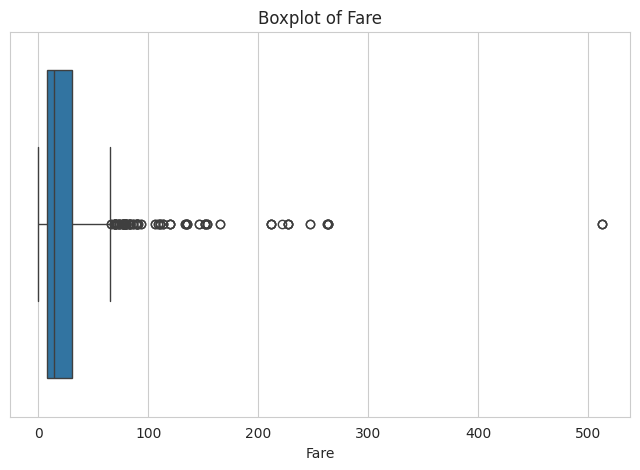

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

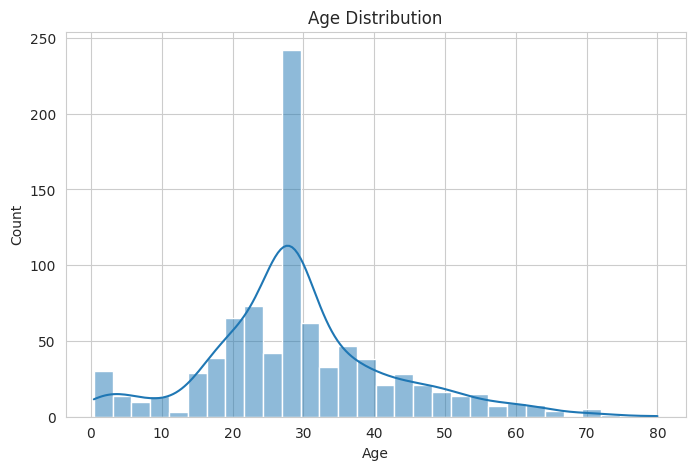

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

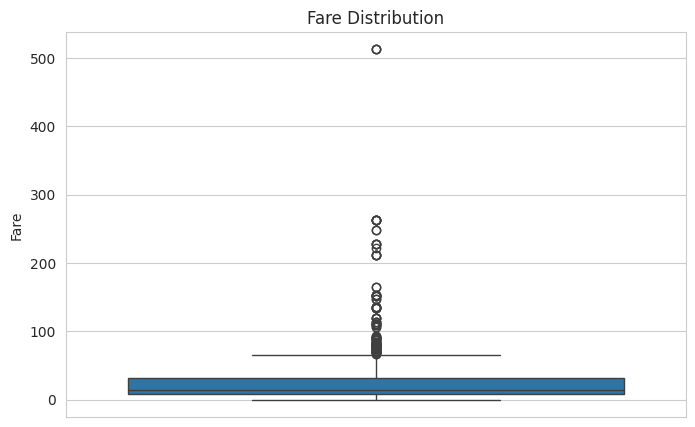

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Fare'])

plt.title("Fare Distribution")
plt.show()

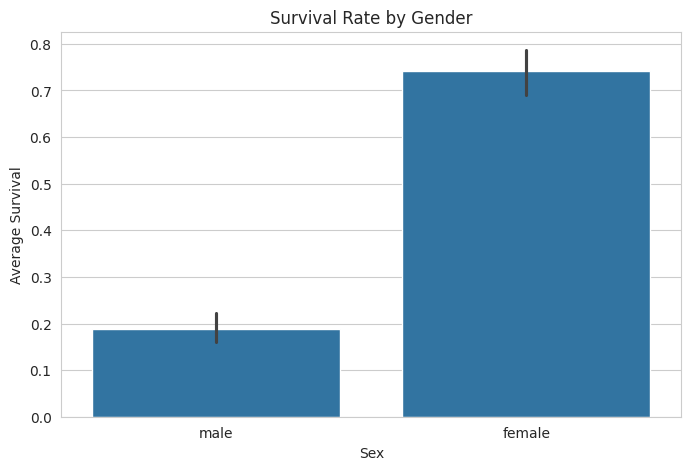

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Sex',
    y='Survived'
)

plt.title("Survival Rate by Gender")
plt.ylabel("Average Survival")

plt.show()

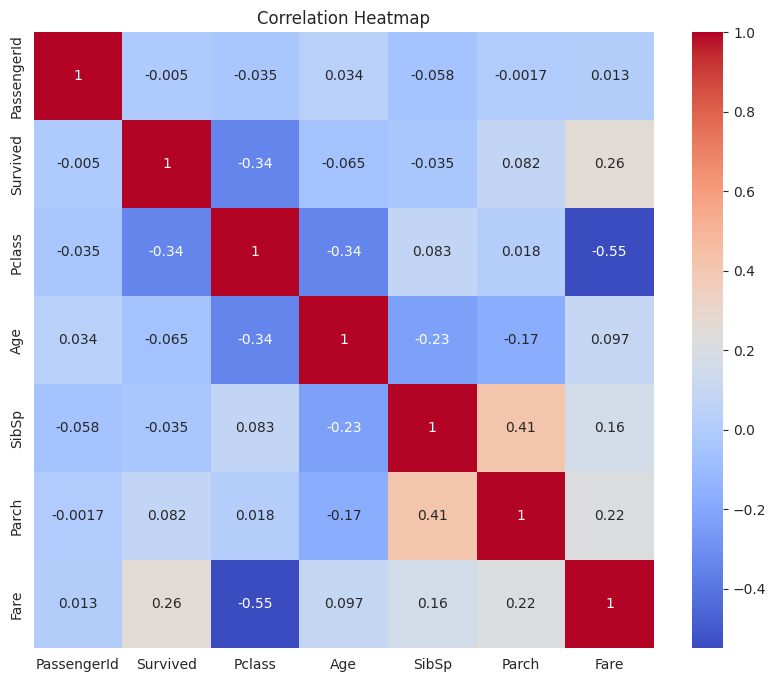

In [15]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Which Feature Most Affects Survival?

Based on the visualizations and exploratory analysis, I believe the Sex feature has the strongest effect on survival.

The survival rate among female passengers is significantly higher than among male passengers. This pattern aligns with the historical evacuation policy of "women and children first" during the Titanic disaster.

Although passenger class (Pclass) and Fare also show relationships with survival, gender appears to be the most influential feature because the difference in survival rates between males and females is very large and consistent throughout the dataset.

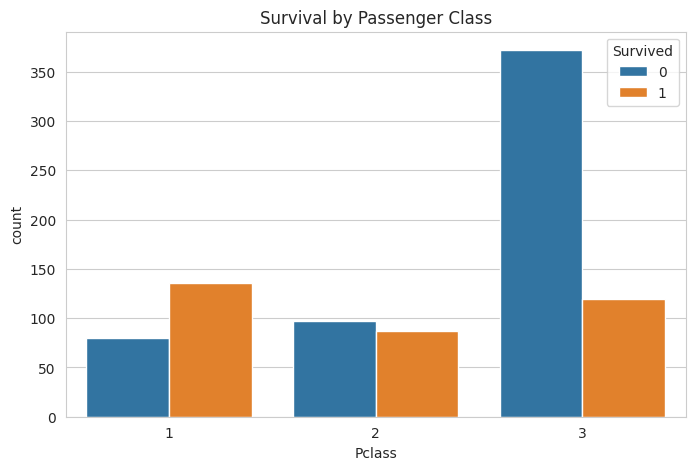

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title("Survival by Passenger Class")

plt.show()